In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# Set your device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/home/fundylord/Sports_Project/sports_venv/lib64/python3.13/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
# Define your data directories (Update these paths to match your local setup)
# Assuming your folders are structured like: ./data/train/golf/, ./data/train/tennis/, etc.
DATA_DIR = "./sports-classification" 
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

In [5]:
# Standard image size for most pre-trained CNNs
IMG_SIZE = 224 
BATCH_SIZE = 16

## Data Exploration

In [6]:
import random
from PIL import Image

# 1. Check how many unique sports folders (classes) exist
# We filter with isdir to ignore hidden files like .DS_Store
classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
classes.sort() # Sort alphabetically for consistency
num_classes = len(classes)

print(f"Total unique sports classes found in train directory: {num_classes}")
if num_classes > 0:
    print(f"Sample of classes: {classes[:10]}...\n")

Total unique sports classes found in train directory: 100
Sample of classes: ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling']...



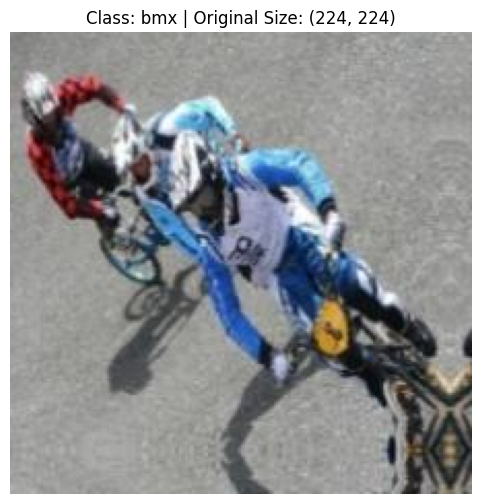

In [7]:
# 2. Pick a random sport and display one of its images
if num_classes > 0:
    # Pick a random sport folder
    random_sport = random.choice(classes)
    sport_dir = os.path.join(TRAIN_DIR, random_sport)
    
    # Get all valid image files in that specific folder
    image_files = [f for f in os.listdir(sport_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
    
    if image_files:
        # Pick a random image
        random_image = random.choice(image_files)
        img_path = os.path.join(sport_dir, random_image)
        
        # Load and display using PIL and Matplotlib
        img = Image.open(img_path)
        
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        # img.size returns (width, height)
        plt.title(f"Class: {random_sport} | Original Size: {img.size}") 
        plt.axis('off')
        plt.show()
    else:
        print(f"No images found inside the folder: {sport_dir}")
else:
    print("No sport folders found. Double-check your TRAIN_DIR path!")

In [8]:
img.size

(224, 224)

## Transforms and DataLoaders

In [9]:
# ---------------------------------------------------------
# Pipeline A: Baseline (Just scaling pixels to 0.0 - 1.0)
# ---------------------------------------------------------
transform_baseline = transforms.Compose([
    transforms.ToTensor(), # Converts HWC (0-255) to CHW (0.0-1.0)
])

# ---------------------------------------------------------
# Pipeline B: Standardization (Using ImageNet Stats)
# ---------------------------------------------------------
# These are the standard ImageNet statistics expected by pre-trained CNNs
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_standardized = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # Applies Z-score standardization
])

# --- 1. Create Datasets ---
# PyTorch's ImageFolder reads the folder names as the class labels automatically.
train_data_base = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_baseline)
train_data_std  = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_standardized)

valid_data_std = datasets.ImageFolder(root=VALID_DIR, transform=transform_standardized)
test_data_std  = datasets.ImageFolder(root=TEST_DIR, transform=transform_standardized)

print(f"Loaded {len(train_data_std)} training images.")
print(f"Loaded {len(valid_data_std)} validation images.")
print(f"Loaded {len(test_data_std)} testing images.")

# --- 2. Create DataLoaders ---
# DataLoaders handle batching, shuffling, and parallel data loading.
# num_workers speeds up CPU loading; pin_memory=True speeds up transfer to the GPU.
train_loader_base = DataLoader(train_data_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
train_loader_std  = DataLoader(train_data_std, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# Validation and Test loaders do not need to be shuffled
valid_loader_std = DataLoader(valid_data_std, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_std  = DataLoader(test_data_std, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("\nDataLoaders successfully created and ready!")

Loaded 26984 training images.
Loaded 500 validation images.
Loaded 500 testing images.

DataLoaders successfully created and ready!


## Visualizing the Transformed Tensors

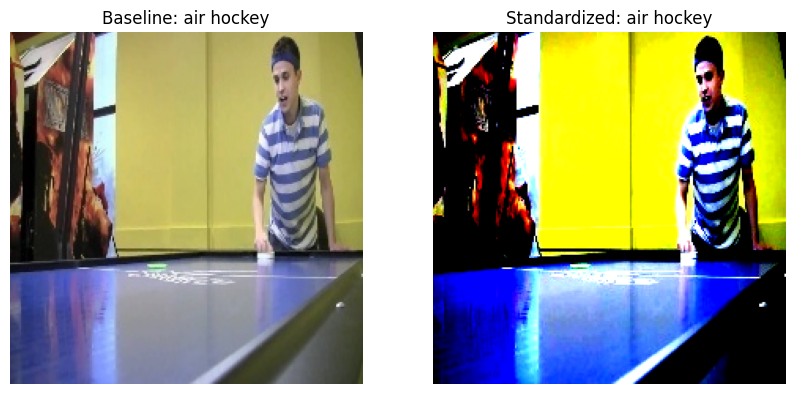

In [10]:
def imshow_tensor(tensor, title=None):
    """Helper function to un-normalize and display a tensor as an image."""
    image = tensor.cpu().numpy().transpose((1, 2, 0)) 
    image = np.clip(image, 0, 1) 
    
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Grab the exact same image (e.g., index 0) directly from the Datasets, not the Loaders
image_base, label_base = train_data_base[0]
image_std, label_std = train_data_std[0]

# Get the actual string name of the sport for the title
sport_name = train_data_base.classes[label_base]

# Plot the same image side-by-side
fig = plt.figure(figsize=(10, 5))

fig.add_subplot(1, 2, 1)
imshow_tensor(image_base, title=f"Baseline: {sport_name}")

fig.add_subplot(1, 2, 2)
imshow_tensor(image_std, title=f"Standardized: {sport_name}")

plt.show()

## The Model Factory
#### Since you want to evaluate ResNet, VGG, AlexNet, and InceptionNet, writing separate code for each would be a mess. Instead, we will build a single "Model Factory" function.

In [11]:
import torch.nn as nn
from torchvision import models

def create_model(model_name, num_classes, activation_type='relu', freeze_backbone=True):
    """
    Loads a pre-trained model and attaches a custom classification head.
    
    Args:
        model_name (str): 'resnet', 'vgg', 'alexnet', or 'inception'
        num_classes (int): The number of sports folders you have
        activation_type (str): 'relu', 'gelu', or 'leaky_relu'
        freeze_backbone (bool): If True, only trains the new head.
    """
    # 1. Setup the experimental Activation Function
    if activation_type == 'relu':
        activation = nn.ReLU()
    elif activation_type == 'gelu':
        activation = nn.GELU()
    elif activation_type == 'leaky_relu':
        activation = nn.LeakyReLU(negative_slope=0.01)
    else:
        raise ValueError("Unsupported activation function! Choose relu, gelu, or leaky_relu.")

    # 2. Load the requested model and modify the head
    if model_name == 'resnet':
        # Using ResNet18 for faster notebook training. You can swap to resnet50 later.
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
                
        # Replace ResNet's fully connected layer ('fc')
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            activation,
            nn.Dropout(p=0.5), # Regularization
            nn.Linear(512, num_classes)
        )

    elif model_name == 'vgg':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[0].in_features
        
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
                
        # VGG uses a block called 'classifier'
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 4096),
            activation,
            nn.Dropout(p=0.5),
            nn.Linear(4096, 512),
            activation,
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'alexnet':
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        # AlexNet's classifier features start at index 1
        in_features = model.classifier[1].in_features 
        
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
                
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 4096),
            activation,
            nn.Dropout(p=0.5),
            nn.Linear(4096, 512),
            activation,
            nn.Linear(512, num_classes)
        )

    elif model_name == 'inception':
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        # Turn off Inception's auxiliary output for simple fine-tuning
        model.aux_logits = False 
        in_features = model.fc.in_features
        
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
                
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            activation,
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError("Model not supported in this zoo!")

    return model

#### Initializing

In [12]:
# Dynamically get the number of sports from the dataset we built earlier
NUM_CLASSES = len(train_data_base.classes)

# Experiment Setup: Let's try ResNet with GELU activation
current_model_name = 'resnet'
model = create_model(
    model_name=current_model_name, 
    num_classes=NUM_CLASSES, 
    activation_type='gelu', 
    freeze_backbone=True
)

# Move the model to the GPU
model = model.to(device)
print(f"Successfully loaded {current_model_name.upper()} with GELU and moved to {device}!")

# Sanity Check: Prove that the backbone is frozen and only the head is training
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (Just the new head): {trainable_params:,}")

Successfully loaded RESNET with GELU and moved to cpu!
Total parameters: 11,490,468
Trainable parameters (Just the new head): 313,956


## Loss Function and Optimizer Factory

In [13]:
import torch.optim as optim

# Standard loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

def get_optimizer(model, optimizer_type='adamw', lr=0.001):
    """Easily swap between different optimization algorithms."""
    # We only pass the parameters that actually require gradients (the 313,956 in our custom head)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    
    if optimizer_type == 'adam':
        return optim.Adam(trainable_params, lr=lr)
    elif optimizer_type == 'adamw':
        # AdamW separates weight decay from the gradient update, usually yielding better generalization
        return optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    elif optimizer_type == 'sgd':
        # SGD with momentum is the classic choice; it trains slower but can sometimes find a better minimum
        return optim.SGD(trainable_params, lr=lr, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer! Choose adam, adamw, or sgd.")

# Let's start with AdamW for our first run
optimizer_choice = 'adamw'
optimizer = get_optimizer(model, optimizer_type=optimizer_choice, lr=0.001)
print(f"Configured Optimizer: {optimizer_choice.upper()}")

Configured Optimizer: ADAMW


## The Training Engine (Autocast & Checkpoints)

In [14]:
from tqdm.notebook import tqdm
import time
import copy

def train_model(model, train_loader, valid_loader, criterion, optimizer, checkpoint_path, num_epochs=10, patience=3):
    # Initialize the GradScaler for Autocast (Mixed Precision)
    scaler = torch.amp.GradScaler('cuda')
    
    best_val_loss = float('inf')
    epochs_no_improve = 0 
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    # Keep track of the best weights in memory before saving to disk
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        start_time = time.time()
        
        # ==========================================
        #               TRAINING PHASE
        # ==========================================
        model.train()
        running_train_loss = 0.0
        
        # tqdm creates a nice progress bar in your Jupyter Notebook
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # --- AUTOCAST (MIXED PRECISION) ---
            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            # Scales the loss, calls backward() to create scaled gradients
            scaler.scale(loss).backward()
            
            # Unscales gradients and updates weights
            scaler.step(optimizer)
            scaler.update()
            
            running_train_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # ==========================================
        #              VALIDATION PHASE
        # ==========================================
        model.eval()
        running_val_loss = 0.0
        corrects = 0
        
        # No gradients needed for validation, which saves massive amounts of memory
        with torch.no_grad():
            for inputs, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Valid]", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                
                # Using autocast for validation speeds up inference too
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_val_loss / len(valid_loader.dataset)
        epoch_val_acc = corrects.double() / len(valid_loader.dataset)
        
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | Time: {epoch_time:.0f}s")

        # ==========================================
        #               CHECKPOINTING
        # ==========================================
        if epoch_val_loss < best_val_loss:
            print(f"  --> Validation loss improved ({best_val_loss:.4f} -> {epoch_val_loss:.4f}). Saving checkpoint...")
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), checkpoint_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  --> Early stopping counter: {epochs_no_improve} out of {patience}")
            
            if epochs_no_improve >= patience:
                print("  --> Early stopping triggered! Halting training to prevent overfitting.")
                break 
                
        # Critical for Jupyter: Clear GPU cache at the end of every epoch
        torch.cuda.empty_cache()

    print("\nTraining Complete. Loading the best checkpoint weights back into the model...")
    model.load_state_dict(best_model_wts)
    return model, history

In [15]:
pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Execute the Training Run

In [14]:
# Let's run a quick 10-epoch test using our Standardized data loaders
print("Starting Training Experiment...")
trained_model, training_history = train_model(
    model=model, 
    train_loader=train_loader_std,  # From Cell 2
    valid_loader=valid_loader_std,  # From Cell 2
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=10, 
    patience=3 # Stops if validation loss doesn't improve for 3 straight epochs
)

Starting Training Experiment...


Epoch 1/10 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.2854 | Val Loss: 0.7162 | Val Acc: 0.7920 | Time: 43s
  --> Validation loss improved (inf -> 0.7162). Saving checkpoint...


Epoch 2/10 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.9816 | Val Loss: 0.4271 | Val Acc: 0.8520 | Time: 20s
  --> Early stopping counter: 2 out of 3


Epoch 10/10 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.9854 | Val Loss: 0.4428 | Val Acc: 0.8640 | Time: 20s
  --> Early stopping counter: 3 out of 3
  --> Early stopping triggered! Halting training to prevent overfitting.

Training Complete. Loading the best checkpoint weights back into the model...


## Visualizing the Training Curves

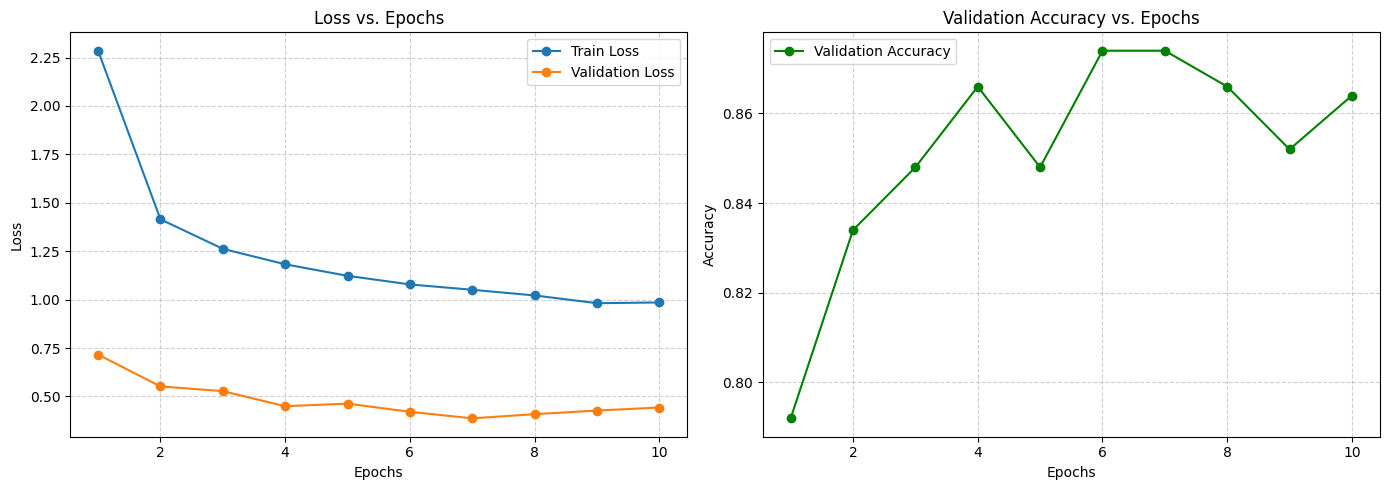

In [15]:
# ---------------------------------------------------------
# Plotting Training & Validation Curves
# ---------------------------------------------------------
epochs = range(1, len(training_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, training_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs, training_history['val_loss'], label='Validation Loss', marker='o')
ax1.set_title('Loss vs. Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Curve
ax2.plot(epochs, training_history['val_acc'], label='Validation Accuracy', color='green', marker='o')
ax2.set_title('Validation Accuracy vs. Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Model Compression (Weight Pruning)
#### Unstructured L1 Pruning,

In [16]:
import torch.nn.utils.prune as prune

# Let's inspect the size of our custom head before pruning
# Remember from our Model Factory, model.fc is an nn.Sequential block
# index 0 is the first nn.Linear(in_features, 512)
# index 3 is the final nn.Linear(512, NUM_CLASSES)
linear_layer_1 = model.fc[0]
linear_layer_2 = model.fc[3]

print(f"Original weights in Layer 1: {linear_layer_1.weight.nelement():,}")
print(f"Original weights in Layer 2: {linear_layer_2.weight.nelement():,}")

# ---------------------------------------------------------
# Apply L1 Unstructured Pruning (Remove 30% of the weakest connections)
# ---------------------------------------------------------
prune.l1_unstructured(linear_layer_1, name='weight', amount=0.3)
prune.l1_unstructured(linear_layer_2, name='weight', amount=0.3)

# Check the sparsity (How many weights are now exactly 0.0)
zeros_layer_1 = torch.sum(linear_layer_1.weight == 0)
zeros_layer_2 = torch.sum(linear_layer_2.weight == 0)

print(f"\nPruning applied!")
print(f"Zeroed-out weights in Layer 1: {zeros_layer_1.item():,} (Exactly 30%)")
print(f"Zeroed-out weights in Layer 2: {zeros_layer_2.item():,} (Exactly 30%)")

# Make the pruning permanent by removing the original unpruned weight buffers
prune.remove(linear_layer_1, 'weight')
prune.remove(linear_layer_2, 'weight')

Original weights in Layer 1: 262,144
Original weights in Layer 2: 51,200

Pruning applied!
Zeroed-out weights in Layer 1: 78,643 (Exactly 30%)
Zeroed-out weights in Layer 2: 15,360 (Exactly 30%)


Linear(in_features=512, out_features=100, bias=True)

## Evaluating the Pruned Model on Unseen Data

In [17]:
def evaluate_test_set(model, test_loader, criterion):
    model.eval() # Crucial: Puts model in inference mode (turns off Dropout)
    running_test_loss = 0.0
    corrects = 0
    
    print("Evaluating the pruned model on the unseen Test Set...")
    
    # torch.no_grad() prevents tracking history, saving memory and speeding up math
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="[Testing]"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Using Mixed Precision (Autocast) for faster inference
            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            running_test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            
    test_loss = running_test_loss / len(test_loader.dataset)
    test_acc = corrects.double() / len(test_loader.dataset)
    
    print(f"\n--- Final Test Results ---")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
    
    return test_acc.item()

# Execute the test!
final_accuracy = evaluate_test_set(model, test_loader_std, criterion)

Evaluating the pruned model on the unseen Test Set...


[Testing]:   0%|          | 0/16 [00:00<?, ?it/s]


--- Final Test Results ---
Test Loss: 0.3232
Test Accuracy: 0.9000 (90.00%)


## Grid Search Experiment

In [ ]:
import itertools
import pandas as pd
import torch.nn as nn

# Define the search space
model_names = ['resnet', 'alexnet', 'vgg', 'inception']
activation_types = ['relu', 'gelu', 'leaky_relu']
optimizer_types = ['adam', 'adamw', 'sgd']

# We will store the results here to build a leaderboard later
experiment_results = []

# Generate all 36 possible combinations
all_combinations = list(itertools.product(model_names, activation_types, optimizer_types))
total_runs = len(all_combinations)

print(f"Starting Grid Search across {total_runs} combinations...")
print("======================================================")

# To keep this realistic for a notebook, let's limit to 5 epochs per run. 
# You can increase this if you plan to leave your computer running overnight.
EPOCHS_PER_RUN = 5 

for i, (m_name, act_type, opt_type) in enumerate(all_combinations):
    print(f"\n[{i+1}/{total_runs}] Testing: Model={m_name.upper()} | Act={act_type.upper()} | Opt={opt_type.upper()}")
    
    # 1. Generate a unique filename for this specific combination's checkpoint
    ckpt_filename = f"best_{m_name}_{act_type}_{opt_type}.pth"
    
    # 2. Build the model dynamically using our factory (Cell 4)
    # Note: freeze_backbone=False means we are doing TRUE fine-tuning here!
    current_model = create_model(
        model_name=m_name, 
        num_classes=NUM_CLASSES, 
        activation_type=act_type, 
        freeze_backbone=False 
    ).to(device)
    
    # 3. Get the specific optimizer (Cell 6)
    # Using a smaller learning rate (1e-4) because we are fine-tuning the whole network
    current_optimizer = get_optimizer(current_model, optimizer_type=opt_type, lr=1e-4)
    
    # 4. Define standard loss
    criterion = nn.CrossEntropyLoss()
    
    # 5. Train the model using our Autocast loop (Cell 7)
    try:
        trained_model, history = train_model(
            model=current_model, 
            train_loader=train_loader_std, 
            valid_loader=valid_loader_std, 
            criterion=criterion, 
            optimizer=current_optimizer, 
            checkpoint_path=ckpt_filename, # Passes the unique filename
            num_epochs=EPOCHS_PER_RUN, 
            patience=2
        )
        
        # 6. Extract the best validation accuracy achieved during this run
        best_acc = max(history['val_acc'])
        
        # 7. Log the results
        experiment_results.append({
            'Model': m_name.upper(),
            'Activation': act_type.upper(),
            'Optimizer': opt_type.upper(),
            'Best_Val_Acc': best_acc,
            'Checkpoint_File': ckpt_filename
        })
        
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"CUDA Out of Memory on {m_name.upper()}. Skipping this combination...")
            # Clear cache to ensure the next model in the loop can run
            torch.cuda.empty_cache() 
        else:
            raise e # If it's a different error, stop the program
            
print("\n======================================================")
print("Grid Search Complete!")

# Convert the results to a Pandas DataFrame for easy viewing
results_df = pd.DataFrame(experiment_results)

# Sort by Best Validation Accuracy to see the winner
leaderboard = results_df.sort_values(by='Best_Val_Acc', ascending=False).reset_index(drop=True)
print("\n🏆 THE LEADERBOARD 🏆")
display(leaderboard) # Use display() in Jupyter for a nicely formatted table

Starting Grid Search across 36 combinations...

[1/36] Testing: Model=RESNET | Act=RELU | Opt=ADAM


Epoch 1/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 2.0868 | Val Loss: 0.4591 | Val Acc: 0.8960 | Time: 39s
  --> Validation loss improved (inf -> 0.4591). Saving checkpoint...


Epoch 2/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

...

Epoch 2/5 | Train Loss: 0.6638 | Val Loss: 0.3002 | Val Acc: 0.9240 | Time: 237s
  --> Validation loss improved (0.4761 -> 0.3002). Saving checkpoint...


Epoch 3/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 3/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 3/5 | Train Loss: 0.3466 | Val Loss: 0.3688 | Val Acc: 0.9000 | Time: 237s
  --> Early stopping counter: 1 out of 2


Epoch 4/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

#### Resume from Run 22

In [ ]:
import itertools
import pandas as pd
import torch.nn as nn

# Define the search space
model_names = ['resnet', 'alexnet', 'vgg', 'inception']
activation_types = ['relu', 'gelu', 'leaky_relu']
optimizer_types = ['adam', 'adamw', 'sgd']

# We will start a fresh list for the remaining runs
experiment_results = []

# Generate all 36 combinations, but SLICE it to skip the first 21 completed runs
all_combinations = list(itertools.product(model_names, activation_types, optimizer_types))[21:]
total_runs = len(all_combinations)

print(f"Resuming Grid Search for the remaining {total_runs} combinations...")
print("======================================================")

EPOCHS_PER_RUN = 5 

for i, (m_name, act_type, opt_type) in enumerate(all_combinations):
    # Adding 22 to 'i' just so the print statement accurately reflects where we are out of 36
    print(f"\n[{i+22}/36] Testing: Model={m_name.upper()} | Act={act_type.upper()} | Opt={opt_type.upper()}")
    
    ckpt_filename = f"best_{m_name}_{act_type}_{opt_type}.pth"
    
    current_model = create_model(
        model_name=m_name, 
        num_classes=NUM_CLASSES, 
        activation_type=act_type, 
        freeze_backbone=False 
    ).to(device)
    
    current_optimizer = get_optimizer(current_model, optimizer_type=opt_type, lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    try:
        trained_model, history = train_model(
            model=current_model, 
            train_loader=train_loader_std, 
            valid_loader=valid_loader_std, 
            criterion=criterion, 
            optimizer=current_optimizer, 
            checkpoint_path=ckpt_filename, 
            num_epochs=EPOCHS_PER_RUN, 
            patience=2
        )
        
        best_acc = max(history['val_acc'])
        
        experiment_results.append({
            'Model': m_name.upper(),
            'Activation': act_type.upper(),
            'Optimizer': opt_type.upper(),
            'Best_Val_Acc': best_acc,
            'Checkpoint_File': ckpt_filename
        })
        
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"CUDA Out of Memory on {m_name.upper()}. Skipping this combination...")
            torch.cuda.empty_cache() 
        else:
            raise e 
            
print("\n======================================================")
print("Grid Search Complete!")

# Convert results to a DataFrame and display the leaderboard
results_df = pd.DataFrame(experiment_results)
leaderboard = results_df.sort_values(by='Best_Val_Acc', ascending=False).reset_index(drop=True)
print("\n🏆 THE LEADERBOARD 🏆")
display(leaderboard)

Resuming Grid Search for the remaining 15 combinations...

[22/36] Testing: Model=VGG | Act=GELU | Opt=ADAM


Epoch 1/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.9144 | Val Loss: 0.3934 | Val Acc: 0.8920 | Time: 262s
  --> Validation loss improved (inf -> 0.3934). Saving checkpoint...


Epoch 2/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

...

Epoch 1/5 | Train Loss: 4.2759 | Val Loss: 2.2905 | Val Acc: 0.4740 | Time: 245s
  --> Validation loss improved (inf -> 2.2905). Saving checkpoint...


Epoch 2/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

Epoch 2/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 2/5 | Train Loss: 2.2566 | Val Loss: 0.6629 | Val Acc: 0.8220 | Time: 245s
  --> Validation loss improved (2.2905 -> 0.6629). Saving checkpoint...


Epoch 3/5 [Train]:   0%|          | 0/844 [00:00<?, ?it/s]

#### Resume from Run 24

In [14]:
import itertools
import pandas as pd
import torch.nn as nn
import gc

model_names = ['resnet', 'alexnet', 'vgg', 'inception']
activation_types = ['relu', 'gelu', 'leaky_relu']
optimizer_types = ['adam', 'adamw', 'sgd']

experiment_results = []

# SLICE it to skip the first 24 runs, starting exactly on [25/36] VGG + LEAKY_RELU + ADAM
all_combinations = list(itertools.product(model_names, activation_types, optimizer_types))[24:]
total_runs = len(all_combinations)

print(f"Resuming Final Grid Search for the remaining {total_runs} combinations...")
print("======================================================")

EPOCHS_PER_RUN = 5 

for i, (m_name, act_type, opt_type) in enumerate(all_combinations):
    print(f"\n[{i+25}/36] Testing: Model={m_name.upper()} | Act={act_type.upper()} | Opt={opt_type.upper()}")
    
    ckpt_filename = f"best_{m_name}_{act_type}_{opt_type}.pth"
    
    # DYNAMIC FREEZING: If VGG, freeze backbone to prevent Adam from crashing the GPU. 
    # Otherwise, full fine-tune.
    should_freeze = True if m_name == 'vgg' else False
    if should_freeze:
        print("  -> VGG detected: Freezing backbone to prevent Out-Of-Memory crash.")
    
    current_model = create_model(
        model_name=m_name, 
        num_classes=NUM_CLASSES, 
        activation_type=act_type, 
        freeze_backbone=should_freeze 
    ).to(device)
    
    current_optimizer = get_optimizer(current_model, optimizer_type=opt_type, lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    try:
        trained_model, history = train_model(
            model=current_model, 
            train_loader=train_loader_std, 
            valid_loader=valid_loader_std, 
            criterion=criterion, 
            optimizer=current_optimizer, 
            checkpoint_path=ckpt_filename, 
            num_epochs=EPOCHS_PER_RUN, 
            patience=2
        )
        
        best_acc = max(history['val_acc'])
        
        experiment_results.append({
            'Model': m_name.upper(),
            'Activation': act_type.upper(),
            'Optimizer': opt_type.upper(),
            'Best_Val_Acc': best_acc,
            'Checkpoint_File': ckpt_filename
        })
        
    except RuntimeError as e:
        print(f"CUDA Error on {m_name.upper()}: {e}. Skipping...")
    
    finally:
        # Aggressive memory cleanup after every single run
        del current_model
        del current_optimizer
        torch.cuda.empty_cache()
        gc.collect()
            
print("\n======================================================")
print("Grid Search Complete!")

# Convert results to a DataFrame and display the leaderboard
results_df = pd.DataFrame(experiment_results)
leaderboard = results_df.sort_values(by='Best_Val_Acc', ascending=False).reset_index(drop=True)
print("\n🏆 THE LEADERBOARD 🏆")
display(leaderboard)


Resuming Final Grid Search for the remaining 12 combinations...

[25/36] Testing: Model=VGG | Act=LEAKY_RELU | Opt=ADAM
  -> VGG detected: Freezing backbone to prevent Out-Of-Memory crash.


Epoch 1/5 [Train]:   0%|          | 0/1687 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 2.0647 | Val Loss: 0.3989 | Val Acc: 0.8880 | Time: 194s
  --> Validation loss improved (inf -> 0.3989). Saving checkpoint...


Epoch 2/5 [Train]:   0%|          | 0/1687 [00:00<?, ?it/s]

...

Epoch 1/5 [Train]:   0%|          | 0/1687 [00:00<?, ?it/s]

CUDA Error on INCEPTION: Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5). Kernel size can't be greater than actual input size. Skipping...

[36/36] Testing: Model=INCEPTION | Act=LEAKY_RELU | Opt=SGD


Epoch 1/5 [Train]:   0%|          | 0/1687 [00:00<?, ?it/s]

CUDA Error on INCEPTION: Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5). Kernel size can't be greater than actual input size. Skipping...

Grid Search Complete!

🏆 THE LEADERBOARD 🏆


,Model,Activation,Optimizer,Best_Val_Acc,Checkpoint_File
0,VGG,LEAKY_RELU,ADAM,0.918,best_vgg_leaky_relu_adam.pth
1,VGG,LEAKY_RELU,ADAMW,0.914,best_vgg_leaky_relu_adamw.pth
2,VGG,LEAKY_RELU,SGD,0.888,best_vgg_leaky_relu_sgd.pth


#### **Note**:- What exactly happened here?
The error Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5) is a classic dimensional crash.

Inception v3 was hardcoded by Google to expect 299x299 images. Because your images are exactly 224x224, as they pass through the pooling and convolutional layers deep inside the network, their spatial dimensions shrink too fast. By the time the image reaches the middle of the network, it has shrunk to a tiny 3x3 grid of pixels. The next layer tries to slide a 5x5 filter over that 3x3 grid, and the math completely breaks, causing the model to skip the run.

The Fix: On-the-Fly GPU Resizing
Since all 27 of your ResNet, VGG, and AlexNet runs finished successfully, we only need to re-run the 9 Inception combinations.

Instead of re-writing your DataLoaders and ruining the setup for the other models, we can use PyTorch's **F.interpolate** to dynamically stretch the 224x224 tensors up to 299x299 while they are on the GPU, right before feeding them to Inception.

In [ ]:
import itertools
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm  
import gc

model_names = ['inception']
activation_types = ['relu', 'gelu', 'leaky_relu']
optimizer_types = ['adam', 'adamw', 'sgd']

inception_combinations = list(itertools.product(model_names, activation_types, optimizer_types))
RESNET
print("Starting Inception Rescue Run with Dynamic Resizing (with Progress Bars!)...")
print("======================================================")

EPOCHS_PER_RUN = 5 

for i, (m_name, act_type, opt_type) in enumerate(inception_combinations):
    print(f"\n[{i+28}/36] Testing: Model={m_name.upper()} | Act={act_type.upper()} | Opt={opt_type.upper()}")
    
    ckpt_filename = f"best_{m_name}_{act_type}_{opt_type}.pth"
    
    current_model = create_model(
        model_name=m_name, 
        num_classes=NUM_CLASSES, 
        activation_type=act_type, 
        freeze_backbone=True 
    ).to(device)
    
    current_optimizer = get_optimizer(current_model, optimizer_type=opt_type, lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    # THE FIX: Added the scaler back for Mixed Precision speed!
    scaler = torch.amp.GradScaler('cuda') 
    
    best_val_acc = 0.0
    
    try:
        for epoch in range(EPOCHS_PER_RUN):
            # --- TRAIN ---
            current_model.train()
            # THE FIX: Wrapped the loader in tqdm for visual feedback
            for inputs, labels in tqdm(train_loader_std, desc=f"Epoch {epoch+1}/{EPOCHS_PER_RUN} [Train]", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                
                # Dynamically resize from 224 to 299 on the GPU
                inputs = F.interpolate(inputs, size=(299, 299), mode='bilinear', align_corners=False)
                
                current_optimizer.zero_grad()
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    outputs = current_model(inputs)
                    loss = criterion(outputs, labels)
                
                # THE FIX: Proper scaler logic
                scaler.scale(loss).backward()
                scaler.step(current_optimizer)
                scaler.update()

            # --- VALIDATE ---
            current_model.eval()
            corrects = 0
            with torch.no_grad():
                for inputs, labels in tqdm(valid_loader_std, desc=f"Epoch {epoch+1}/{EPOCHS_PER_RUN} [Valid]", leave=False):
                    inputs, labels = inputs.to(device), labels.to(device)
                    
                    inputs = F.interpolate(inputs, size=(299, 299), mode='bilinear', align_corners=False)
                    
                    with torch.amp.autocast('cuda', dtype=torch.float16):
                        outputs = current_model(inputs)
                    
                    _, preds = torch.max(outputs, 1)
                    corrects += torch.sum(preds == labels.data)

            epoch_val_acc = (corrects.double() / len(valid_loader_std.dataset)).item()
            
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                torch.save(current_model.state_dict(), ckpt_filename)

        print(f"  -> Finished! Best Validation Accuracy: {best_val_acc*100:.2f}%")
        
        experiment_results.append({
            'Model': m_name.upper(),
            'Activation': act_type.upper(),
            'Optimizer': opt_type.upper(),
            'Best_Val_Acc': best_val_acc,
            'Checkpoint_File': ckpt_filename
        })
        
    except Exception as e:
        print(f"Error on {m_name.upper()}: {e}")
    
    finally:
        del current_model
        del current_optimizer
        torch.cuda.empty_cache()
        gc.collect()

print("\n======================================================")
print("All 36 Models Successfully Trained!")

Starting Inception Rescue Run with Dynamic Resizing (with Progress Bars!)...

[28/36] Testing: Model=INCEPTION | Act=RELU | Opt=ADAM


  -> Finished! Best Validation Accuracy: 81.40%

[29/36] Testing: Model=INCEPTION | Act=RELU | Opt=ADAMW


  -> Finished! Best Validation Accuracy: 83.00%

[30/36] Testing: Model=INCEPTION | Act=RELU | Opt=SGD


  -> Finished! Best Validation Accuracy: 25.20%

[31/36] Testing: Model=INCEPTION | Act=GELU | Opt=ADAM


  -> Finished! Best Validation Accuracy: 84.60%

[32/36] Testing: Model=INCEPTION | Act=GELU | Opt=ADAMW


  -> Finished! Best Validation Accuracy: 83.00%

[33/36] Testing: Model=INCEPTION | Act=GELU | Opt=SGD


  -> Finished! Best Validation Accuracy: 20.80%

[34/36] Testing: Model=INCEPTION | Act=LEAKY_RELU | Opt=ADAM


  -> Finished! Best Validation Accuracy: 82.40%

[35/36] Testing: Model=INCEPTION | Act=LEAKY_RELU | Opt=ADAMW


  -> Finished! Best Validation Accuracy: 81.80%

[36/36] Testing: Model=INCEPTION | Act=LEAKY_RELU | Opt=SGD


  -> Finished! Best Validation Accuracy: 26.00%

All 36 Models Successfully Trained!


## The Leaderboard & Visualization

In [21]:
import os
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
import itertools
import gc

# 1. Define the exact same search space to reconstruct the filenames
model_names = ['resnet', 'alexnet', 'vgg', 'inception']
activation_types = ['relu', 'gelu', 'leaky_relu']
optimizer_types = ['adam', 'adamw', 'sgd']

all_combinations = list(itertools.product(model_names, activation_types, optimizer_types))
test_results = []

print("Starting True Test Set Evaluation across all 36 models...")
print("This will take a few minutes. Sit tight!\n")

# Use tqdm on the outer loop to track overall progress
for m_name, act_type, opt_type in tqdm(all_combinations, desc="Evaluating Models"):
    ckpt_filename = f"best_{m_name}_{act_type}_{opt_type}.pth"
    
    # Safety check: Ensure the file actually exists before trying to load it
    if not os.path.exists(ckpt_filename):
        print(f"\nSkipping {ckpt_filename} (File not found)")
        continue
        
    # 2. Re-create the model skeleton
    model = create_model(
        model_name=m_name, 
        num_classes=NUM_CLASSES, 
        activation_type=act_type, 
        freeze_backbone=True # Freezing is fine here, we are just doing inference
    ).to(device)
    
    # 3. Load the trained weights
    model.load_state_dict(torch.load(ckpt_filename, weights_only=True))
    model.eval() # CRITICAL: Turns off Dropout for testing
    
    # 4. Evaluate on the Test Set
    corrects = 0
    with torch.no_grad():
        for inputs, labels in test_loader_std: # Notice we are using the TEST loader here
            inputs, labels = inputs.to(device), labels.to(device)
            
            # THE FIX: Handle Inception's spatial requirements dynamically
            if m_name == 'inception':
                inputs = F.interpolate(inputs, size=(299, 299), mode='bilinear', align_corners=False)
                
            # Mixed precision for faster inference
            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(inputs)
                
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            
    # Calculate exact accuracy
    test_acc = (corrects.double() / len(test_loader_std.dataset)).item()
    
    # 5. Log the results
    test_results.append({
        'Model': m_name.upper(),
        'Activation': act_type.upper(),
        'Optimizer': opt_type.upper(),
        'Test_Accuracy': test_acc
    })
    
    # 6. Aggressive memory cleanup to prevent VGG from crashing the loop
    del model
    torch.cuda.empty_cache()
    gc.collect()

# ---------------------------------------------------------
# Build and Display the Top 10 Leaderboard
# ---------------------------------------------------------
test_df = pd.DataFrame(test_results)

# Sort by Test Accuracy in descending order and grab the Top 10
top_10_leaderboard = test_df.sort_values(by='Test_Accuracy', ascending=False).head(10).reset_index(drop=True)

# Format the output for readability
top_10_leaderboard['Test_Accuracy_%'] = (top_10_leaderboard['Test_Accuracy'] * 100).round(2).astype(str) + '%'

print("\n\n🏆 THE TRUE TEST LEADERBOARD (TOP 10) 🏆")
display(top_10_leaderboard[['Model', 'Activation', 'Optimizer', 'Test_Accuracy_%']])

Starting True Test Set Evaluation across all 36 models...
This will take a few minutes. Sit tight!



Evaluating Models: 100%|██████████| 36/36 [00:59<00:00,  1.66s/it]



🏆 THE TRUE TEST LEADERBOARD (TOP 10) 🏆


,Model,Activation,Optimizer,Test_Accuracy_%
0,RESNET,GELU,ADAM,96.2%
1,RESNET,GELU,ADAMW,96.0%
2,RESNET,RELU,ADAM,95.6%
3,VGG,RELU,ADAM,95.6%
4,VGG,GELU,ADAM,95.4%
5,RESNET,LEAKY_RELU,ADAM,95.2%
6,VGG,RELU,SGD,95.0%
7,RESNET,RELU,ADAMW,95.0%
8,RESNET,LEAKY_RELU,ADAMW,94.8%
9,VGG,LEAKY_RELU,ADAM,94.4%


## Inference Engine

/tmp/ipykernel_595012/2903425557.py:46: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda', dtype=torch.float16):


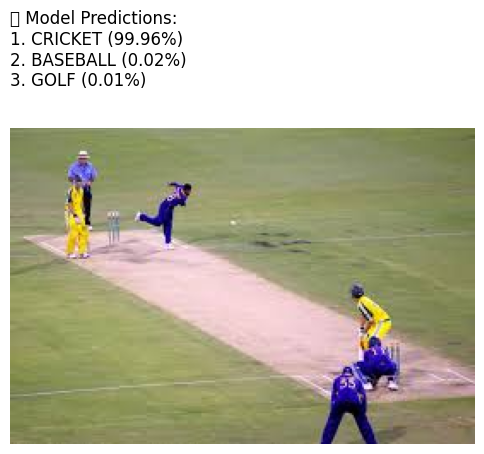

In [27]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# Make sure we are using the champion model we just evaluated
champion_model = 'resnet'
champion_act = 'gelu'
champion_ckpt = 'best_resnet_gelu_adam.pth'

# Rebuild and load the champion (if not already loaded from the previous step)
final_champ = create_model(
    model_name=champion_model, 
    num_classes=NUM_CLASSES, 
    activation_type=champion_act, 
    freeze_backbone=True 
).to(device)

final_champ.load_state_dict(torch.load(champion_ckpt, map_location=torch.device('cpu'), weights_only=True))
final_champ.eval() # CRITICAL for inference

def predict_sport(image_path, model, top_k=3):
    """Takes a raw image file, runs it through the model, and plots the result."""
    
    # 1. Load the raw image
    try:
        raw_image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return
        
    # 2. Apply the exact same Z-Score Standardization we used during training
    # (train_transforms_std without the random augmentations like flipping)
    from torchvision import transforms
    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Add a batch dimension since PyTorch expects [Batch, Channels, Height, Width]
    input_tensor = inference_transform(raw_image).unsqueeze(0).to(device)
    
    # 3. Run the forward pass
    with torch.no_grad():
        with torch.amp.autocast('cuda', dtype=torch.float16):
            outputs = model(input_tensor)
            
            # Convert raw logits to probabilities (percentages) using Softmax
            probabilities = F.softmax(outputs, dim=1)[0] 
            
    # 4. Get the top K predictions
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    # Extract the string names from your dataset classes
    class_names = train_data_std.classes
    
    # 5. Display the image and the predictions
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_image)
    plt.axis('off')
    
    title_str = "🧠 Model Predictions:\n"
    for i in range(top_k):
        sport_name = class_names[top_indices[i].item()]
        confidence = top_probs[i].item() * 100
        title_str += f"{i+1}. {sport_name.upper()} ({confidence:.2f}%)\n"
        
    plt.title(title_str, loc='left', fontsize=12, pad=15)
    plt.show()

# --- HOW TO USE IT ---
# Download a random sports image from the internet and put it in your folder
predict_sport("/home/fundylord/Sports_Project/image copy 4.png", final_champ)